## E-Commerce Sales Analysis - Superstore Dataset

This notebook analyzes the Sample Superstore dataset using **only pandas, numpy, and matplotlib** (no plotly/seaborn).

**Objectives:**
1. Monthly sales — highest & lowest month
2. Sales by product category — highest & lowest
3. Sales by sub-category
4. Monthly profit — highest profit month
5. Profit by category & sub-category
6. Sales & profit by customer segment
7. Sales-to-profit ratio

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.alpha'] = 0.3

## Load the data

In [35]:
data = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
print("Shape:", data.shape)
data.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [36]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [38]:
# data.duplicated()
data.duplicated().sum()

np.int64(0)

In [39]:
data.isnull()  # find True or False Value
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Drop Unwanted Column


In [40]:
# data.drop(columns=["Postal Code","Segment"],axis=1,inplace=True)

## Data Preparation

Convert the date columns to datetime and derive Month/Year fields, which are needed for the
time-based (monthly) sales and profit analysis.

In [41]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month
data['Order Month Name'] = data['Order Date'].dt.strftime('%b')
data['Order Day of Week'] = data['Order Date'].dt.dayofweek

data[['Order Date', 'Order Year', 'Order Month', 'Order Month Name']].head()

,Order Date,Order Year,Order Month,Order Month Name
0,2016-11-08,2016,11,Nov
1,2016-11-08,2016,11,Nov
2,2016-06-12,2016,6,Jun
3,2015-10-11,2015,10,Oct
4,2015-10-11,2015,10,Oct


## 1. Monthly Sales Analysis

Sales are aggregated by calendar month (across all years in the dataset) to see the overall
seasonal pattern, and to identify the best and worst performing months.

In [42]:
monthly_sales = data.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales['Month Name'] = pd.to_datetime(monthly_sales['Order Month'], format='%m').dt.strftime('%b')
monthly_sales = monthly_sales.sort_values('Order Month').reset_index(drop=True)
monthly_sales


,Order Month,Sales,Month Name
0,1,94924.8356,Jan
1,2,59751.2514,Feb
2,3,205005.4888,Mar
3,4,137762.1286,Apr
4,5,155028.8117,May
5,6,152718.6793,Jun
6,7,147238.0970,Jul
7,8,159044.0630,Aug
8,9,307649.9457,Sep
9,10,200322.9847,Oct


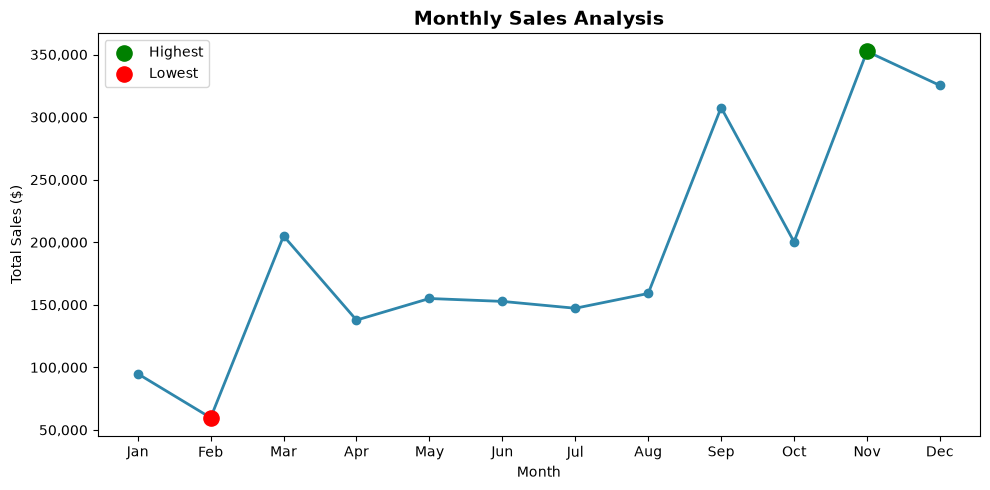

In [43]:
fig, ax = plt.subplots()
ax.plot(monthly_sales['Month Name'], monthly_sales['Sales'], marker='o', color='#2E86AB', linewidth=2)
ax.set_title('Monthly Sales Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

max_idx = monthly_sales['Sales'].idxmax()
min_idx = monthly_sales['Sales'].idxmin()
ax.scatter(monthly_sales['Month Name'][max_idx], monthly_sales['Sales'][max_idx], color='green', s=120, zorder=5, label='Highest')
ax.scatter(monthly_sales['Month Name'][min_idx], monthly_sales['Sales'][min_idx], color='red', s=120, zorder=5, label='Lowest')
ax.legend()
plt.tight_layout()
plt.savefig("Monthly sales analysis.png")
plt.show()


In [44]:
highest_sales_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
lowest_sales_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(f"Highest sales month: {highest_sales_month['Month Name']} (${highest_sales_month['Sales']:,.2f})")
print(f"Lowest sales month:  {lowest_sales_month['Month Name']} (${lowest_sales_month['Sales']:,.2f})")

Highest sales month: Nov ($352,461.07)
Lowest sales month:  Feb ($59,751.25)


## 2. Sales Analysis by Product Category

Compares total sales across the three main product categories to find which category
drives the most and least revenue.

In [45]:
category_sales = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

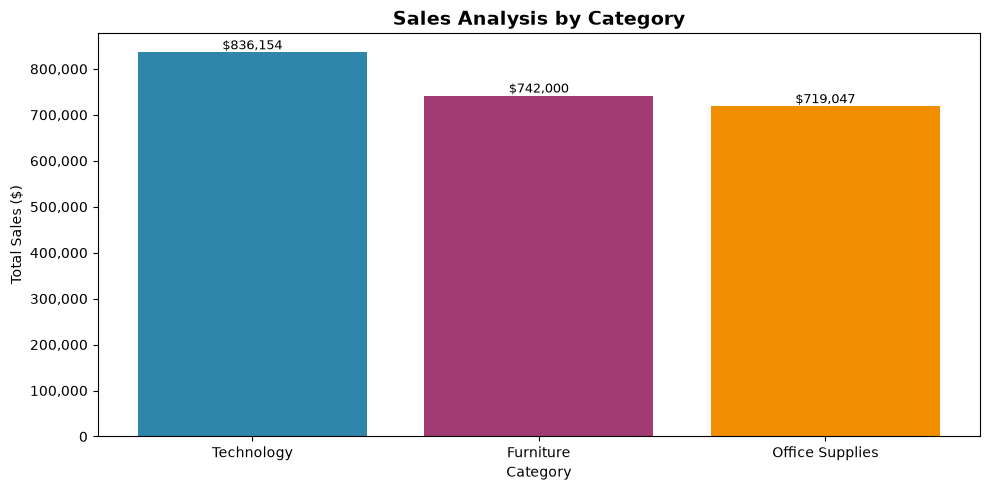

In [46]:
fig, ax = plt.subplots()
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax.bar(category_sales.index, category_sales.values, color=colors)
ax.set_title('Sales Analysis by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in bars:
    ax.annotate(f'${bar.get_height():,.0f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("Sales Analysis by Category.png")
plt.show()

In [47]:
print(f"Highest sales category: {category_sales.idxmax()} (${category_sales.max():,.2f})")
print(f"Lowest sales category:  {category_sales.idxmin()} (${category_sales.min():,.2f})")

Highest sales category: Technology ($836,154.03)
Lowest sales category:  Office Supplies ($719,047.03)


## 3. Sales Analysis by Sub-Category

A more granular view of sales performance within each sub-category.

In [48]:
subcategory_sales = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcategory_sales


Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

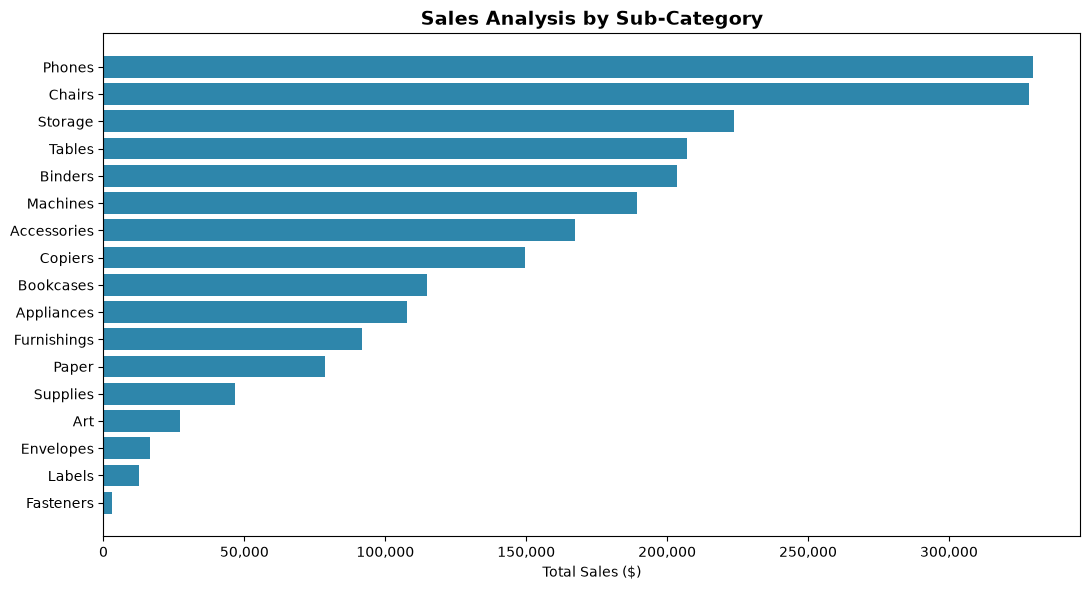

In [49]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(subcategory_sales.index[::-1], subcategory_sales.values[::-1], color='#2E86AB')
ax.set_title('Sales Analysis by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig("Sales analysis by Sub-Category.png")
plt.show()

In [50]:
print(f"Highest sales sub-category: {subcategory_sales.idxmax()} (${subcategory_sales.max():,.2f})")
print(f"Lowest sales sub-category:  {subcategory_sales.idxmin()} (${subcategory_sales.min():,.2f})")

Highest sales sub-category: Phones ($330,007.05)
Lowest sales sub-category:  Fasteners ($3,024.28)


## 4. Monthly Profit Analysis

Profit aggregated by month to identify the most profitable month.

In [51]:
monthly_profit = data.groupby('Order Month')['Profit'].sum().reset_index()
monthly_profit['Month Name'] = pd.to_datetime(monthly_profit['Order Month'], format='%m').dt.strftime('%b')
monthly_profit = monthly_profit.sort_values('Order Month').reset_index(drop=True)
monthly_profit


,Order Month,Profit,Month Name
0,1,9134.4461,Jan
1,2,10294.6107,Feb
2,3,28594.6872,Mar
3,4,11587.4363,Apr
4,5,22411.3078,May
5,6,21285.7954,Jun
6,7,13832.6648,Jul
7,8,21776.9384,Aug
8,9,36857.4753,Sep
9,10,31784.0413,Oct


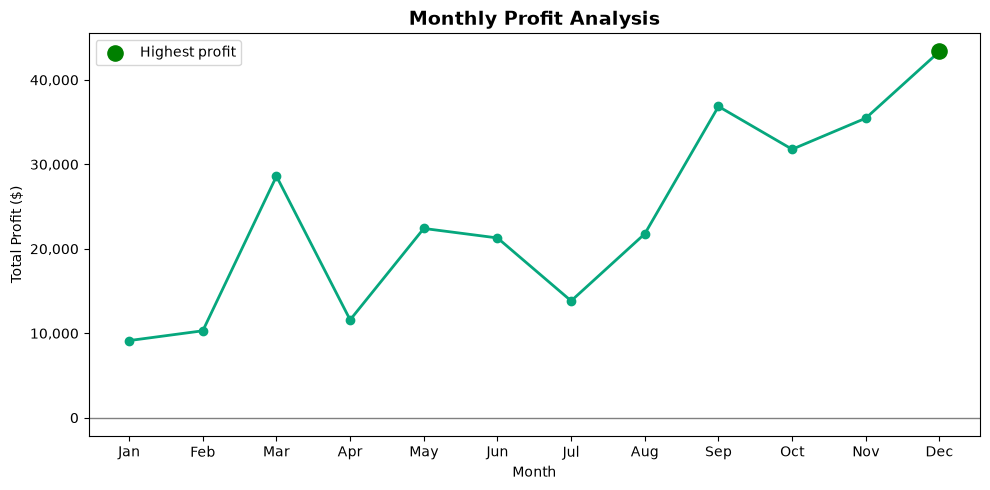

In [52]:
fig, ax = plt.subplots()
ax.plot(monthly_profit['Month Name'], monthly_profit['Profit'], marker='o', color='#06A77D', linewidth=2)
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Monthly Profit Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

max_idx = monthly_profit['Profit'].idxmax()
ax.scatter(monthly_profit['Month Name'][max_idx], monthly_profit['Profit'][max_idx], color='green', s=120, zorder=5, label='Highest profit')
ax.legend()
plt.tight_layout()
plt.savefig("Monthly Profit analysis.png")
plt.show()


In [53]:
highest_profit_month = monthly_profit.loc[monthly_profit['Profit'].idxmax()]
lowest_profit_month = monthly_profit.loc[monthly_profit['Profit'].idxmin()]

print(f"Highest profit month: {highest_profit_month['Month Name']} (${highest_profit_month['Profit']:,.2f})")
print(f"Lowest profit month:  {lowest_profit_month['Month Name']} (${lowest_profit_month['Profit']:,.2f})")

Highest profit month: Dec ($43,369.19)
Lowest profit month:  Jan ($9,134.45)


## 5. Profit Analysis by Category & Sub-Category

In [54]:
category_profit = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit


Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

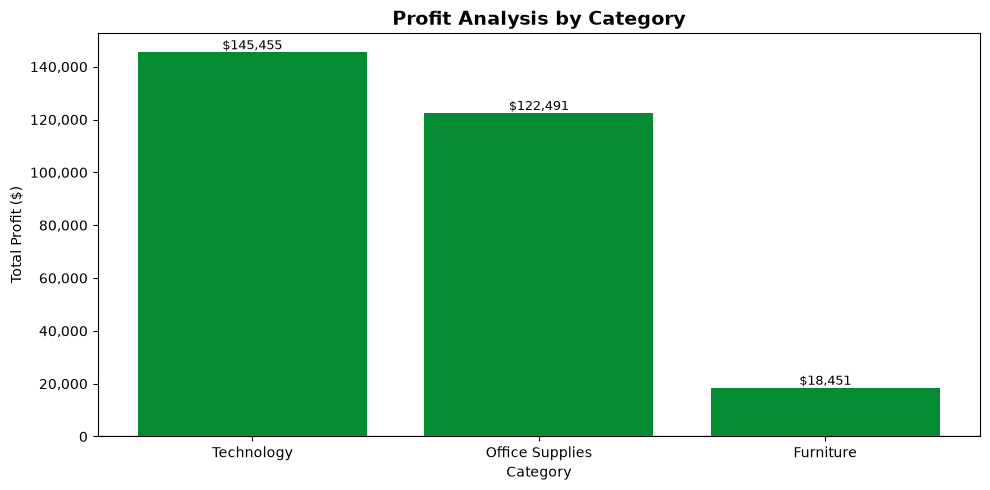

In [55]:
fig, ax = plt.subplots()
colors = ["#058B31" if v >= 0 else '#D62246' for v in category_profit.values]
bars = ax.bar(category_profit.index, category_profit.values, color=colors)
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Profit Analysis by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in bars:
    ax.annotate(f'${bar.get_height():,.0f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom' if bar.get_height() >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.savefig("Profit Analysis by Category.png")
plt.show()

In [56]:
subcategory_profit = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
subcategory_profit


Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

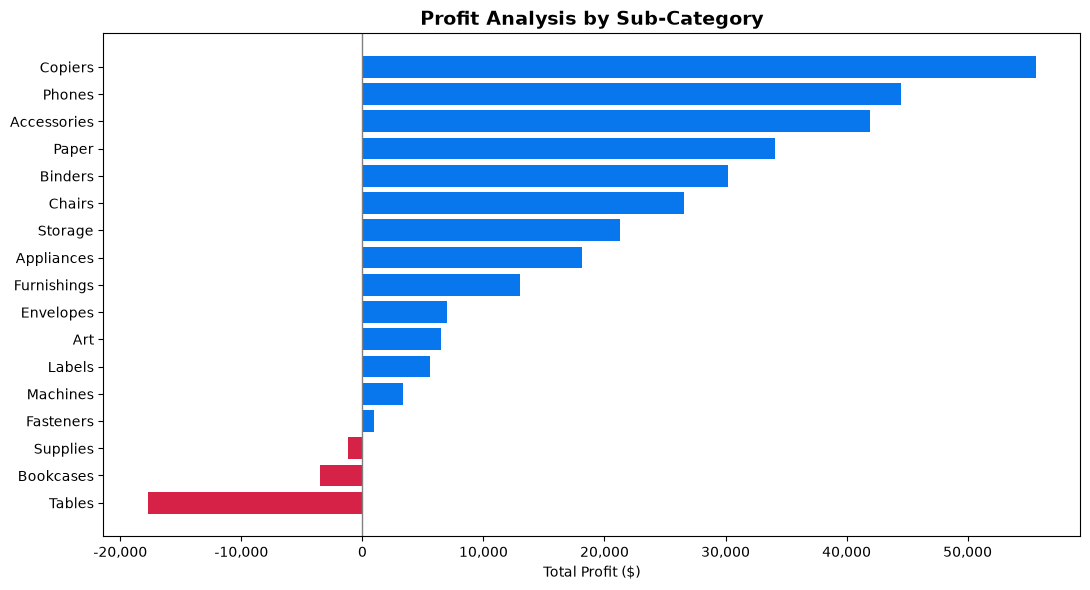

In [57]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#0877ED" if v >= 0 else '#D62246' for v in subcategory_profit.values[::-1]]
ax.barh(subcategory_profit.index[::-1], subcategory_profit.values[::-1], color=colors)
ax.axvline(0, color='gray', linewidth=1)
ax.set_title('Profit Analysis by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig("Profit Analysis by Sub-Catagory.png")
plt.show()


In [58]:
print(f"Most profitable category: {category_profit.idxmax()} (${category_profit.max():,.2f})")
print(f"Least profitable category: {category_profit.idxmin()} (${category_profit.min():,.2f})")
print()
print(f"Most profitable sub-category:  {subcategory_profit.idxmax()} (${subcategory_profit.max():,.2f})")
print(f"Least profitable sub-category: {subcategory_profit.idxmin()} (${subcategory_profit.min():,.2f})  <- loss")

Most profitable category: Technology ($145,454.95)
Least profitable category: Furniture ($18,451.27)

Most profitable sub-category:  Copiers ($55,617.82)
Least profitable sub-category: Tables ($-17,725.48)  <- loss


## 6. Sales & Profit Analysis by Customer Segment

In [59]:
segment_summary = data.groupby('Segment').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
segment_summary = segment_summary.sort_values('Sales', ascending=False).reset_index(drop=True)
segment_summary

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


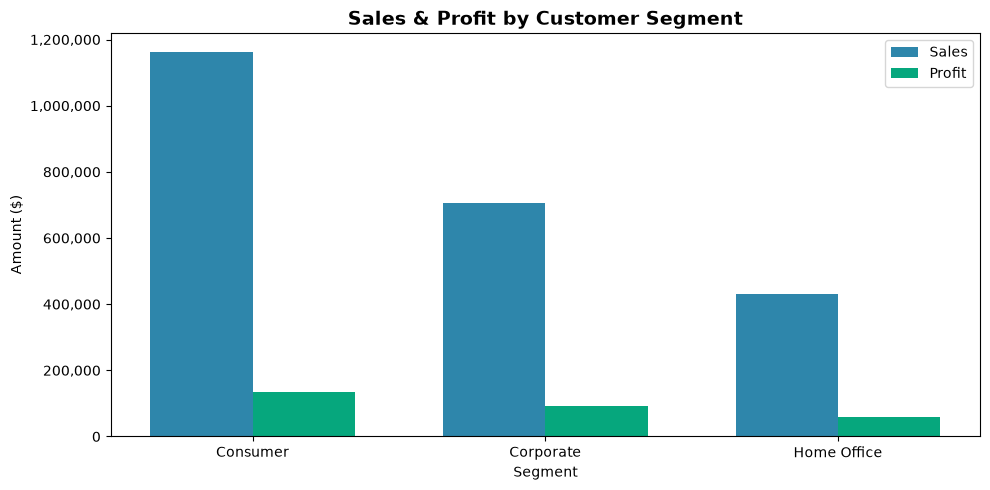

In [60]:
x = np.arange(len(segment_summary))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, segment_summary['Sales'], width, label='Sales', color='#2E86AB')
ax.bar(x + width/2, segment_summary['Profit'], width, label='Profit', color='#06A77D')

ax.set_title('Sales & Profit by Customer Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(segment_summary['Segment'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig("Sales and Profit by Customer Segment.png")
plt.show()

In [61]:
print(f"Segment with highest sales:  {segment_summary.loc[segment_summary['Sales'].idxmax(), 'Segment']}")
print(f"Segment with highest profit: {segment_summary.loc[segment_summary['Profit'].idxmax(), 'Segment']}")

Segment with highest sales:  Consumer
Segment with highest profit: Consumer


## 7. Sales-to-Profit Ratio

The sales-to-profit ratio shows how many dollars of sales are needed to generate one dollar of
profit for each segment. A **lower** ratio means the segment converts sales into profit more
efficiently.

In [62]:
segment_summary['Sales_to_Profit_Ratio'] = segment_summary['Sales'] / segment_summary['Profit']
segment_summary['Profit_Margin_%'] = (segment_summary['Profit'] / segment_summary['Sales']) * 100
segment_summary

,Segment,Sales,Profit,Sales_to_Profit_Ratio,Profit_Margin_%
0,Consumer,1.161401e+06,134119.2092,8.659471,11.548050
1,Corporate,7.061464e+05,91979.1340,7.677245,13.025506
2,Home Office,4.296531e+05,60298.6785,7.125416,14.034269


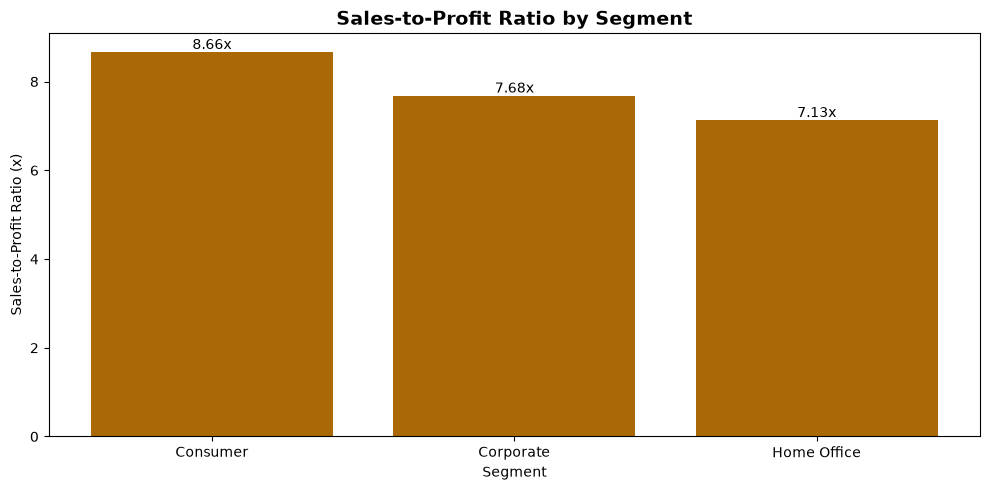

In [63]:
fig, ax = plt.subplots()
bars = ax.bar(segment_summary['Segment'], segment_summary['Sales_to_Profit_Ratio'], color="#AA6806")
ax.set_title('Sales-to-Profit Ratio by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Sales-to-Profit Ratio (x)')
for bar in bars:
    ax.annotate(f'{bar.get_height():.2f}x', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("Sales to Profit Ratio by Segment.png")
plt.show()

In [64]:
most_efficient = segment_summary.loc[segment_summary['Sales_to_Profit_Ratio'].idxmin(), 'Segment']
least_efficient = segment_summary.loc[segment_summary['Sales_to_Profit_Ratio'].idxmax(), 'Segment']
print(f"Most profit-efficient segment (lowest sales-to-profit ratio):  {most_efficient}")
print(f"Least profit-efficient segment (highest sales-to-profit ratio): {least_efficient}")

Most profit-efficient segment (lowest sales-to-profit ratio):  Home Office
Least profit-efficient segment (highest sales-to-profit ratio): Consumer


### Sales-to-Profit Ratio by Category (bonus view)

In [65]:
category_summary = data.groupby('Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
category_summary['Sales_to_Profit_Ratio'] = category_summary['Sales'] / category_summary['Profit']
category_summary['Profit_Margin_%'] = (category_summary['Profit'] / category_summary['Sales']) * 100
category_summary.sort_values('Sales_to_Profit_Ratio')

,Category,Sales,Profit,Sales_to_Profit_Ratio,Profit_Margin_%
2,Technology,836154.0330,145454.9481,5.748543,17.395712
1,Office Supplies,719047.0320,122490.8008,5.870213,17.035158
0,Furniture,741999.7953,18451.2728,40.214017,2.486695


## Key Findings

summary of all findings.

In [66]:

print("SUMMARY OF KEY FINDINGS")

print(f"1. Monthly Sales      -> Highest: {highest_sales_month['Month Name']} (${highest_sales_month['Sales']:,.0f}) | Lowest: {lowest_sales_month['Month Name']} (${lowest_sales_month['Sales']:,.0f})")
print(f"2. Category Sales     -> Highest: {category_sales.idxmax()} (${category_sales.max():,.0f}) | Lowest: {category_sales.idxmin()} (${category_sales.min():,.0f})")
print(f"3. Sub-Category Sales -> Highest: {subcategory_sales.idxmax()} (${subcategory_sales.max():,.0f}) | Lowest: {subcategory_sales.idxmin()} (${subcategory_sales.min():,.0f})")
print(f"4. Monthly Profit     -> Highest: {highest_profit_month['Month Name']} (${highest_profit_month['Profit']:,.0f})")
print(f"5. Category Profit    -> Highest: {category_profit.idxmax()} (${category_profit.max():,.0f}) | Lowest: {category_profit.idxmin()} (${category_profit.min():,.0f})")
print(f"   Sub-Category Profit-> Highest: {subcategory_profit.idxmax()} (${subcategory_profit.max():,.0f}) | Lowest: {subcategory_profit.idxmin()} (${subcategory_profit.min():,.0f})")
print(f"6. Segment            -> Best Sales: {segment_summary.loc[segment_summary['Sales'].idxmax(), 'Segment']} | Best Profit: {segment_summary.loc[segment_summary['Profit'].idxmax(), 'Segment']}")
print(f"7. Sales-to-Profit    -> Most efficient: {most_efficient} | Least efficient: {least_efficient}")



SUMMARY OF KEY FINDINGS
1. Monthly Sales      -> Highest: Nov ($352,461) | Lowest: Feb ($59,751)
2. Category Sales     -> Highest: Technology ($836,154) | Lowest: Office Supplies ($719,047)
3. Sub-Category Sales -> Highest: Phones ($330,007) | Lowest: Fasteners ($3,024)
4. Monthly Profit     -> Highest: Dec ($43,369)
5. Category Profit    -> Highest: Technology ($145,455) | Lowest: Furniture ($18,451)
   Sub-Category Profit-> Highest: Copiers ($55,618) | Lowest: Tables ($-17,725)
6. Segment            -> Best Sales: Consumer | Best Profit: Consumer
7. Sales-to-Profit    -> Most efficient: Home Office | Least efficient: Consumer
